# **CIM Assignment 5:** Experiments with Hybrid Video Encoding/Decoding Scheme

Afonso Cruz UP202204984  
Tomás Kulzer UP202207332


##  Part 1: Hybrid Video Encoder



In [23]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.fftpack import dct, idct
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict
import heapq

---
## 1.1.i — Sequence Import and Colour Space Conversion

The functions `extract_frames` and `crop_frames_to_multiples_of_8` are taken **directly** from the `extractFramesFromVideoAndCrop.ipynb` script provided by the professor, without any modification.


In [24]:
def extract_frames(video_path):
    """Extract grayscale frames from a video."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames

def crop_frames_to_multiples_of_8(video_path):
    """Extract frames from a video, cropping dimensions to multiples of 8."""
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, image = cap.read()
        if not ret:
            break
        height, width = image.shape[:2]
        new_height = (height // 8) * 8
        new_width  = (width  // 8) * 8
        frame = image[:new_height, :new_width]
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)
    cap.release()
    return frames


COLOR_SPACES = {
    'YCrCb' : cv2.COLOR_BGR2YCrCb,
    'HSV'   : cv2.COLOR_BGR2HSV,
    'LAB'   : cv2.COLOR_BGR2LAB,
    'GRAY'  : cv2.COLOR_BGR2GRAY,
    'YUV'   : cv2.COLOR_BGR2YUV,
}

def load_image_sequence(folder_path, extension='.bmp', color_space='YCrCb'):
    """
    1.1.i — Loads an image sequence from a folder,
    converts it to the specified colour space (parameter) and returns:
      - frames_y   : luminance (Y) channel of each frame
      - frames_full: full converted image (all channels)

    Parameters
    ----------
    folder_path  : path to the folder containing the images
    extension    : file extension ('.bmp', '.png', etc.)
    color_space  : target colour space ('YCrCb', 'YUV', 'HSV', 'LAB', 'GRAY')
    """
    if color_space not in COLOR_SPACES:
        raise ValueError(f"Invalid colour space. Choose from: {list(COLOR_SPACES.keys())}")

    files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(extension)
    ])

    if not files:
        raise FileNotFoundError(f"No '{extension}' files found in {folder_path}")

    frames_y    = []
    frames_full = []

    for fname in files:
        img_bgr = cv2.imread(os.path.join(folder_path, fname))
        if img_bgr is None:
            print(f"[WARNING] Could not load {fname}")
            continue

        # Crop to multiples of 8
        h, w = img_bgr.shape[:2]
        img_bgr = img_bgr[:(h//8)*8, :(w//8)*8]

        if color_space == 'GRAY':
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES['GRAY'])
            frames_y.append(converted)
            frames_full.append(converted)
        else:
            converted = cv2.cvtColor(img_bgr, COLOR_SPACES[color_space])
            y_channel = converted[:, :, 0]   # Y channel (luminance)
            frames_y.append(y_channel)
            frames_full.append(converted)

    print(f"[load_image_sequence] Loaded {len(frames_y)} frames from '{folder_path}'")
    print(f"  Colour space: {color_space} | Resolution: {frames_y[0].shape}")
    return frames_y, frames_full


def display_frames(frames_y, title='Sequência de frames (Y)', n_show=5):
    """Display the first n_show frames of the Y channel."""
    n = min(n_show, len(frames_y))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(frames_y[i], cmap='gray')
        ax.set_title(f'Frame {i+1}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

print("Functions 1.1.i defined successfully.")


Functions 1.1.i defined successfully.


[load_image_sequence] Loaded 11 frames from 'video sequences/sequence of still images - car'
  Colour space: YCrCb | Resolution: (256, 256)
Number of frames loaded     : 11
Resolution (H×W)            : (256, 256)
Dtype                       : uint8
Value range (min/max)       : 0 / 255


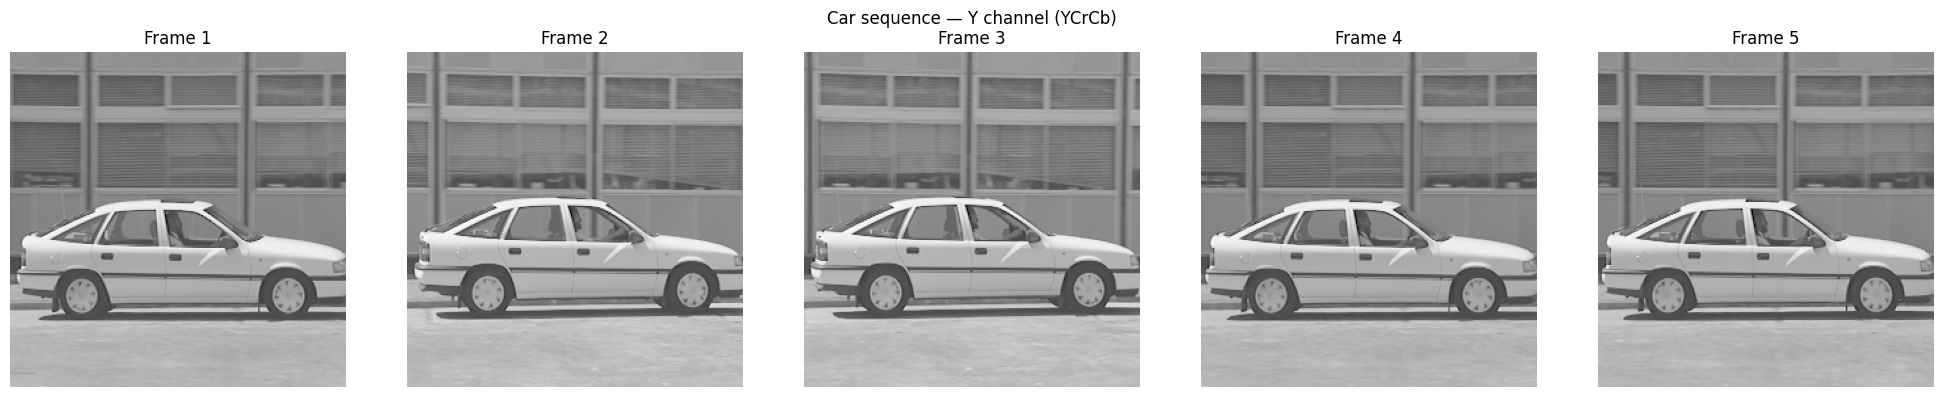

[load_image_sequence] Loaded 11 frames from 'video sequences/sequence of still images - car'
  Colour space: YCrCb | Resolution: (256, 256)
[load_image_sequence] Loaded 11 frames from 'video sequences/sequence of still images - car'
  Colour space: YUV | Resolution: (256, 256)
[load_image_sequence] Loaded 11 frames from 'video sequences/sequence of still images - car'
  Colour space: LAB | Resolution: (256, 256)


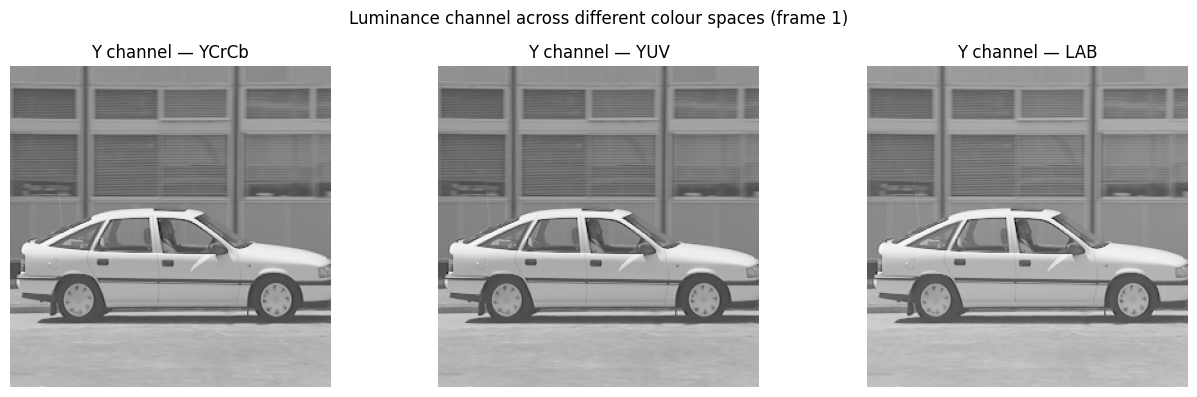

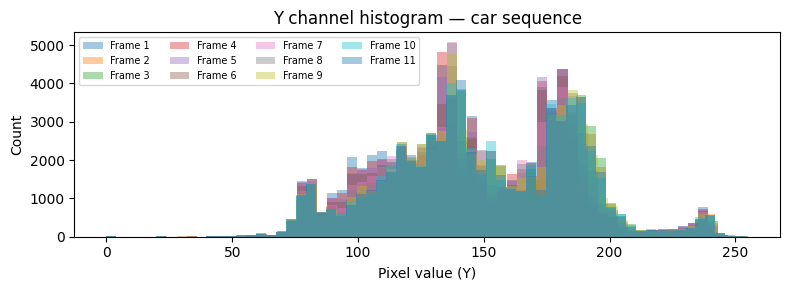

[VIDEO] Extracted 240 frames | resolution: (360, 864)


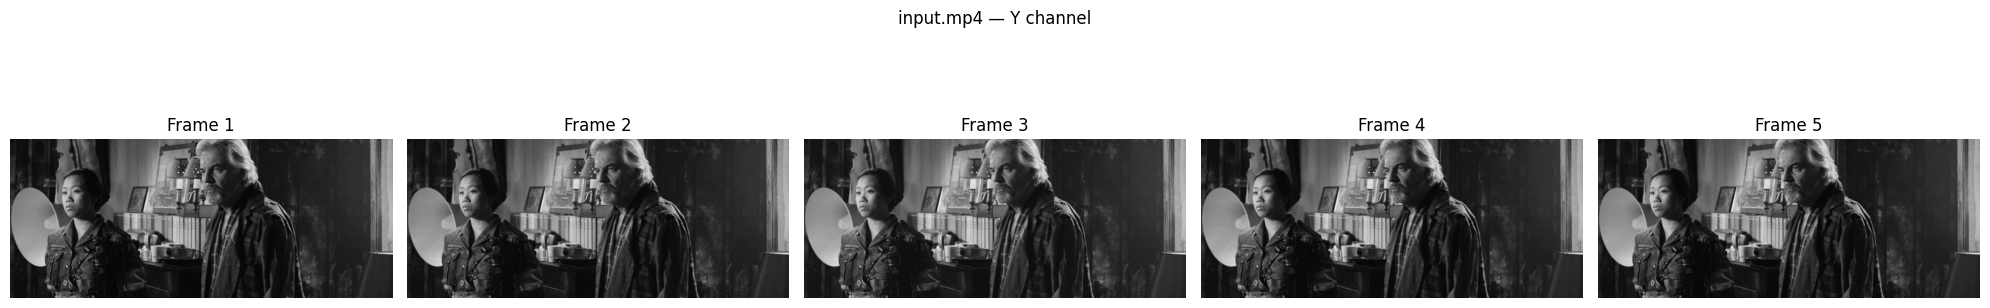

In [25]:
# --- Demo 1.1.i ---
CAR_FOLDER = 'video sequences/sequence of still images - car'
VIDEO_PATH = 'video sequences/input.mp4'

# BMP image sequence (car folder)
if os.path.isdir(CAR_FOLDER):
    frames_y_car, frames_full_car = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')
    print(f"Number of frames loaded     : {len(frames_y_car)}")
    print(f"Resolution (H×W)            : {frames_y_car[0].shape}")
    print(f"Dtype                       : {frames_y_car[0].dtype}")
    print(f"Value range (min/max)       : {frames_y_car[0].min()} / {frames_y_car[0].max()}")
    display_frames(frames_y_car, title='Car sequence — Y channel (YCrCb)', n_show=5)

    # Comparison of Y channels across different colour spaces
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, cs in zip(axes, ['YCrCb', 'YUV', 'LAB']):
        fy, _ = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space=cs)
        ax.imshow(fy[0], cmap='gray')
        ax.set_title(f'Y channel — {cs}')
        ax.axis('off')
    plt.suptitle('Luminance channel across different colour spaces (frame 1)')
    plt.tight_layout(); plt.show()

    # Y channel histogram
    fig, ax = plt.subplots(figsize=(8, 3))
    for idx_f, f in enumerate(frames_y_car):
        ax.hist(f.flatten(), bins=64, alpha=0.4, label=f'Frame {idx_f+1}')
    ax.set_xlabel('Pixel value (Y)')
    ax.set_ylabel('Count')
    ax.set_title('Y channel histogram — car sequence')
    ax.legend(fontsize=7, ncol=4)
    plt.tight_layout(); plt.show()
else:
    print(f"[INFO] Folder '{CAR_FOLDER}' not found.")

# MP4 video (using the professor's function)
if os.path.isfile(VIDEO_PATH):
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    print(f"[VIDEO] Extracted {len(frames_video)} frames | resolution: {frames_video[0].shape}")
    display_frames(frames_video, title='input.mp4 — Y channel', n_show=5)
else:
    print(f"[INFO] Video '{VIDEO_PATH}' not found.")



---
## 1.1.ii & 1.1.iii — Motion Estimation (Block Matching)

The base `block_matching` function is taken **directly** do script `MEblockMatching.ipynb` fornecido pela professora.  
A versão extendida (1.1.iii) adds support for variable MB sizes (16×16 → 4×4) and I/P/B modes.


In [26]:
def mse(block1, block2):
    return np.mean((block1 - block2) ** 2)

def block_matching(ref_frame, target_frame, block_size=16, search_range=8):
    """Full-search block matching motion estimation (professor's code)."""
    height, width = ref_frame.shape
    motion_vectors = np.zeros((height // block_size, width // block_size, 2), dtype=int)

    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):
            best_mse = float('inf')
            best_mv  = (0, 0)
            block    = target_frame[i:i+block_size, j:j+block_size]

            for x in range(-search_range, search_range + 1):
                for y in range(-search_range, search_range + 1):
                    if (0 <= i + x < height - block_size + 1 and
                        0 <= j + y < width  - block_size + 1):
                        candidate = ref_frame[i+x : i+x+block_size, j+y : j+y+block_size]
                        error = mse(block, candidate)
                        if error < best_mse:
                            best_mse = error
                            best_mv  = (x, y)

            motion_vectors[i // block_size, j // block_size] = best_mv
    return motion_vectors


def compute_motion_and_residual(anchor_frame, ref_frames, mode='P',
                                 pixel_accuracy=1, search_range=15,
                                 block_size=16, min_block_size=16):
    """
    1.1.ii / 1.1.iii — Computes motion vectors and the residual frame.

    Parameters
    ----------
    anchor_frame   : frame to encode (np.ndarray 2D, uint8)
    ref_frames     : lista com 1 frame (P mode) ou 2 frames (B mode)
    mode           : 'I', 'P' or 'B'
    pixel_accuracy : pixel accuracy (1 = integer; sub-pixel not implemented here)
    search_range   : search window size (default=15)
    block_size     : maximum MB size (default=16)
    min_block_size : minimum MB size — subdivides recursively down to this value

    Returns
    -------
    mv_list    : list of tuples (row_mb, col_mb, dx, dy, mb_size)
    residual   : difference frame (int16)
    """
    anchor = anchor_frame.astype(np.int16)
    H, W   = anchor.shape
    residual = np.zeros_like(anchor)
    mv_list  = []

    if mode == 'I':
        # Intra mode — no temporal prediction; residual = original frame
        return [], anchor.copy()

    # For P and B always use at least ref_frames[0] as forward reference
    ref_fwd = ref_frames[0].astype(np.int16)
    ref_bwd = ref_frames[1].astype(np.int16) if (mode == 'B' and len(ref_frames) > 1) else None

    mb = block_size
    for i in range(0, H - mb + 1, mb):
        for j in range(0, W - mb + 1, mb):
            blk_anchor = anchor[i:i+mb, j:j+mb]

            # --- Forward search ---
            best_mse_fwd = float('inf')
            best_mv_fwd  = (0, 0)
            for dx in range(-search_range, search_range + 1):
                for dy in range(-search_range, search_range + 1):
                    ri, rj = i + dx, j + dy
                    if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                        cand = ref_fwd[ri:ri+mb, rj:rj+mb]
                        err  = float(np.mean((blk_anchor - cand) ** 2))
                        if err < best_mse_fwd:
                            best_mse_fwd = err
                            best_mv_fwd  = (dx, dy)

            dx_f, dy_f = best_mv_fwd
            pred_fwd   = ref_fwd[i+dx_f : i+dx_f+mb, j+dy_f : j+dy_f+mb]

            if mode == 'B' and ref_bwd is not None:
                # --- Backward search ---
                best_mse_bwd = float('inf')
                best_mv_bwd  = (0, 0)
                for dx in range(-search_range, search_range + 1):
                    for dy in range(-search_range, search_range + 1):
                        ri, rj = i + dx, j + dy
                        if 0 <= ri < H - mb + 1 and 0 <= rj < W - mb + 1:
                            cand = ref_bwd[ri:ri+mb, rj:rj+mb]
                            err  = float(np.mean((blk_anchor - cand) ** 2))
                            if err < best_mse_bwd:
                                best_mse_bwd = err
                                best_mv_bwd  = (dx, dy)
                dx_b, dy_b = best_mv_bwd
                pred_bwd   = ref_bwd[i+dx_b : i+dx_b+mb, j+dy_b : j+dy_b+mb]
                # Bidirectional prediction = average of the two
                pred = ((pred_fwd.astype(np.float32) + pred_bwd.astype(np.float32)) / 2).astype(np.int16)
                mv_list.append((i // mb, j // mb, dx_f, dy_f, dx_b, dy_b, mb))
            else:
                pred = pred_fwd
                mv_list.append((i // mb, j // mb, dx_f, dy_f, mb))

            residual[i:i+mb, j:j+mb] = blk_anchor - pred

    return mv_list, residual


print("Functions 1.1.ii / 1.1.iii defined successfully.")


Functions 1.1.ii / 1.1.iii defined successfully.


---
## 1.1.iv — Motion Vector Visualisation


In [27]:
def plot_motion_vectors(frame, mv_list, mode='P', block_size=16, title='Motion Vectors'):
    """
    1.1.iv — Displays per-macroblock motion vectors overlaid on the frame.

    Parameters
    ----------
    frame      : reference frame (2D, uint8)
    mv_list    : list returned by compute_motion_and_residual
    mode       : 'P' or 'B'
    block_size : MB size
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(frame, cmap='gray')

    for mv in mv_list:
        if mode == 'B' and len(mv) == 7:
            row_mb, col_mb, dx_f, dy_f, dx_b, dy_b, mb = mv
        else:
            row_mb, col_mb, dx_f, dy_f, mb = mv[:5]
            dx_b, dy_b = None, None

        # Block centre
        cx = col_mb * mb + mb // 2
        cy = row_mb * mb + mb // 2

        # Forward arrow (blue)
        if dx_f != 0 or dy_f != 0:
            ax.annotate('', xy=(cx + dy_f, cy + dx_f), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2))

        # Backward arrow (red, B mode only)
        if dx_b is not None and (dx_b != 0 or dy_b != 0):
            ax.annotate('', xy=(cx + dy_b, cy + dx_b), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

    fwd_patch = mpatches.Patch(color='cyan',  label='Forward MV')
    bwd_patch = mpatches.Patch(color='red',   label='Backward MV (B-frame)')
    ax.legend(handles=[fwd_patch, bwd_patch], loc='upper right')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


print("Function 1.1.iv defined successfully.")


Function 1.1.iv defined successfully.


[block_matching — professor] MV grid shape: (16, 16, 2)
  MV[0,0]=[1 0]  MV[1,1]=[-7 -1]  MV[2,2]=[-3 -8]
  Mean MV magnitude: 6.58 px | max: 11.31 px

[compute_motion_and_residual] P mode | 256 MVs
  Residual — mean: 11.31 | max: 236
[compute_motion_and_residual] B mode | 256 MVs
  Residual B — mean: 7.76 | max: 135


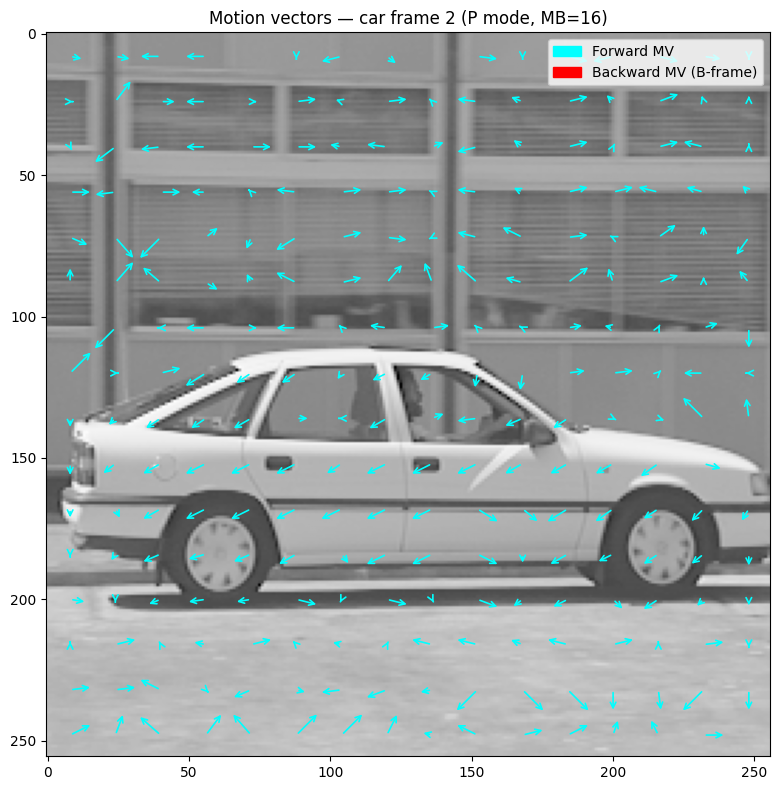

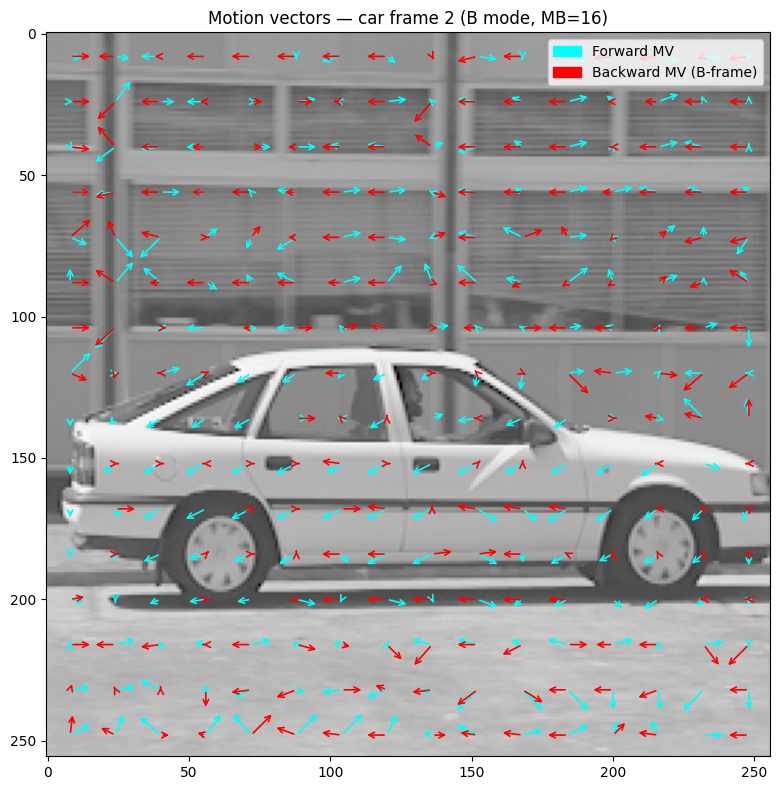

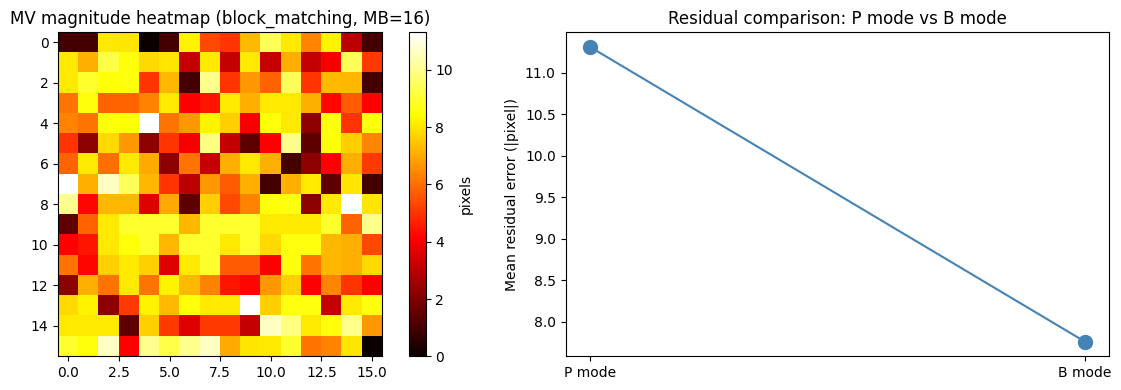

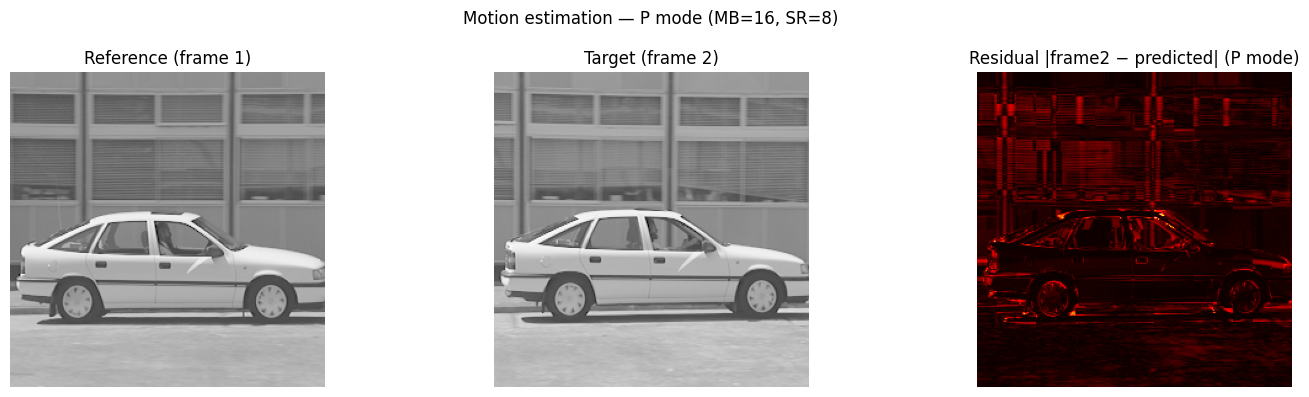


--- Effect of MB size on mean residual ---
  MB=16×16 | mean residual: 11.3106
  MB= 8× 8 | mean residual: 9.1387
  MB= 4× 4 | mean residual: 7.5211


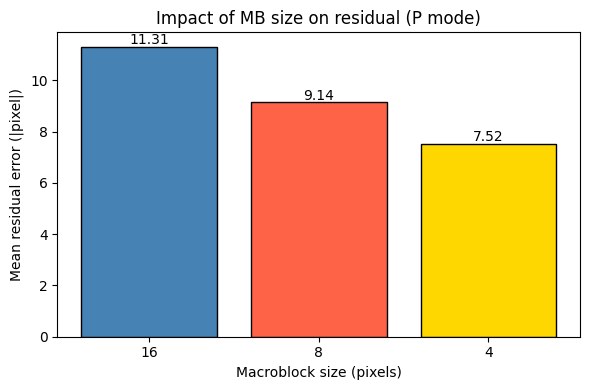

In [28]:
# --- Demo 1.1.ii–iv: MV estimation between consecutive frames ---

if 'frames_y_car' in dir() and len(frames_y_car) >= 3:
    f0 = frames_y_car[0]
    f1 = frames_y_car[1]
    f2 = frames_y_car[2]

    # --- P mode (1.1.ii) — original professor's function ---
    mv_simple = block_matching(f0, f1, block_size=16, search_range=8)
    print(f"[block_matching — professor] MV grid shape: {mv_simple.shape}")
    print(f"  MV[0,0]={mv_simple[0,0]}  MV[1,1]={mv_simple[1,1]}  MV[2,2]={mv_simple[2,2]}")
    magnitudes = np.sqrt(mv_simple[...,0]**2 + mv_simple[...,1]**2)
    print(f"  Mean MV magnitude: {magnitudes.mean():.2f} px | max: {magnitudes.max():.2f} px")

    # --- Extended P mode (1.1.ii/iii) ---
    mv_list_P, residual_P = compute_motion_and_residual(
        f1, [f0], mode='P', search_range=8, block_size=16)
    print(f"\n[compute_motion_and_residual] P mode | {len(mv_list_P)} MVs")
    print(f"  Residual — mean: {np.mean(np.abs(residual_P)):.2f} | max: {np.max(np.abs(residual_P))}")

    # --- B mode (1.1.iii) ---
    mv_list_B, residual_B = compute_motion_and_residual(
        f1, [f0, f2], mode='B', search_range=8, block_size=16)
    print(f"[compute_motion_and_residual] B mode | {len(mv_list_B)} MVs")
    print(f"  Residual B — mean: {np.mean(np.abs(residual_B)):.2f} | max: {np.max(np.abs(residual_B))}")

    # --- MV visualisation P mode (1.1.iv) ---
    plot_motion_vectors(f1, mv_list_P, mode='P', block_size=16,
                        title='Motion vectors — car frame 2 (P mode, MB=16)')

    # --- MV visualisation B mode (1.1.iv) ---
    plot_motion_vectors(f1, mv_list_B, mode='B', block_size=16,
                        title='Motion vectors — car frame 2 (B mode, MB=16)')

    # --- MV magnitude heatmap ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im0 = axes[0].imshow(magnitudes, cmap='hot', interpolation='nearest')
    axes[0].set_title('MV magnitude heatmap (block_matching, MB=16)')
    plt.colorbar(im0, ax=axes[0], label='pixels')
    # Residual P vs B
    axes[1].plot([np.mean(np.abs(residual_P)), np.mean(np.abs(residual_B))],
                 'o-', color='steelblue', markersize=10)
    axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['P mode', 'B mode'])
    axes[1].set_ylabel('Mean residual error (|pixel|)')
    axes[1].set_title('Residual comparison: P mode vs B mode')
    plt.tight_layout(); plt.show()

    # --- Original / predicted / residual frame ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(f0,                   cmap='gray'); axes[0].set_title('Reference (frame 1)')
    axes[1].imshow(f1,                   cmap='gray'); axes[1].set_title('Target (frame 2)')
    axes[2].imshow(np.abs(residual_P),   cmap='hot');  axes[2].set_title('Residual |frame2 − predicted| (P mode)')
    for ax in axes: ax.axis('off')
    plt.suptitle('Motion estimation — P mode (MB=16, SR=8)')
    plt.tight_layout(); plt.show()

    # --- Effect of MB size on residual (1.1.iii) ---
    print("\n--- Effect of MB size on mean residual ---")
    mb_sizes   = [16, 8, 4]
    res_means  = []
    for mb in mb_sizes:
        _, res = compute_motion_and_residual(f1, [f0], mode='P', search_range=8, block_size=mb)
        mean_res = np.mean(np.abs(res))
        res_means.append(mean_res)
        print(f"  MB={mb:2d}×{mb:2d} | mean residual: {mean_res:.4f}")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([str(m) for m in mb_sizes], res_means, color=['steelblue','tomato','gold'], edgecolor='black')
    ax.set_xlabel('Macroblock size (pixels)')
    ax.set_ylabel('Mean residual error (|pixel|)')
    ax.set_title('Impact of MB size on residual (P mode)')
    for i, v in enumerate(res_means):
        ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)
    plt.tight_layout(); plt.show()

else:
    print("[INFO] frames_y_car not available or < 3 frames.")



---
## 1.1.v — DCT2 Transform on 8×8 Blocks

The `apply_dct` and `apply_idct` functions follow the pattern from the **annex** provided by the professor (`scipy.fftpack`).


In [29]:
def apply_dct(block):
    """Apply DCT2 to an 8x8 block (professor's annex)."""
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def apply_idct(block):
    """Apply IDCT2 to an 8x8 block (professor's annex)."""
    return idct(idct(block.T, norm='ortho').T, norm='ortho')


def apply_dct_to_frame(frame, block_size=8):
    """
    1.1.v — Applies DCT2 to every block_size x block_size block of a frame.
    Returns an array of DCT coefficients (float64, same size as the frame).
    """
    H, W = frame.shape
    dct_frame = np.zeros_like(frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = frame[i:i+block_size, j:j+block_size].astype(np.float64)
            if blk.shape == (block_size, block_size):
                dct_frame[i:i+block_size, j:j+block_size] = apply_dct(blk)
    return dct_frame

def apply_idct_to_frame(dct_frame, block_size=8):
    """
    1.1.v — Applies IDCT2 to every block_size x block_size block.
    Returns the reconstructed frame (float64).
    """
    H, W = dct_frame.shape
    rec_frame = np.zeros_like(dct_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                rec_frame[i:i+block_size, j:j+block_size] = apply_idct(blk)
    return rec_frame


print("Functions 1.1.v (DCT2) defined successfully.")


Functions 1.1.v (DCT2) defined successfully.


Original 8×8 block:
[[147 147 148 146 147 148 147 147]
 [148 147 147 147 148 146 146 147]
 [147 146 149 147 147 146 148 146]
 [147 145 146 146 146 147 147 147]
 [147 147 146 146 146 147 145 145]
 [147 147 146 147 147 147 144 145]
 [146 146 146 147 146 145 146 146]
 [146 147 146 146 146 145 146 144]]
DCT2 coefficients (rounded):
[[ 1.1716e+03  2.1000e+00 -8.0000e-01  7.0000e-01  1.0000e-01  2.0000e-01
   5.0000e-01  6.0000e-01]
 [ 3.7000e+00 -1.2000e+00  7.0000e-01 -2.0000e-01 -2.0000e-01  1.0000e-01
   1.4000e+00  1.3000e+00]
 [ 4.0000e-01  3.0000e-01 -1.0000e-01 -8.0000e-01 -4.0000e-01 -4.0000e-01
  -1.0000e+00  6.0000e-01]
 [ 1.0000e-01  6.0000e-01 -3.0000e-01  1.0000e+00  3.0000e-01 -1.8000e+00
   1.0000e+00 -1.7000e+00]
 [-9.0000e-01 -7.0000e-01  8.0000e-01  1.0000e+00 -1.4000e+00 -1.0000e-01
   3.0000e-01 -5.0000e-01]
 [ 2.0000e-01 -2.1000e+00  5.0000e-01 -8.0000e-01 -3.0000e-01  1.2000e+00
   5.0000e-01  3.0000e-01]
 [ 5.0000e-01  7.0000e-01 -1.0000e+00  1.0000e-01 -1.3000e+00  1

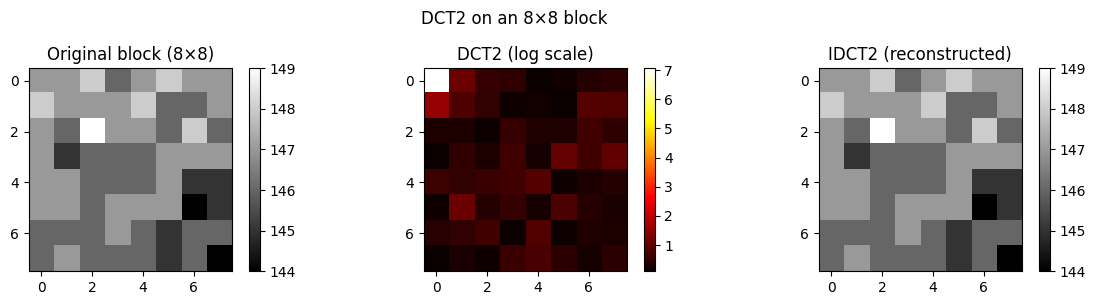


Full-frame DCT2 — max. reconstruction error: 1.99e-13


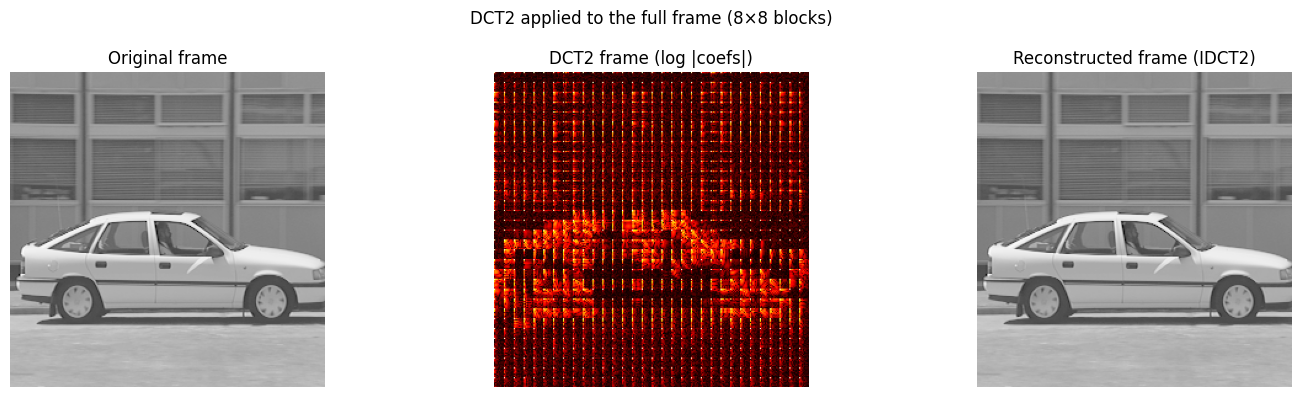

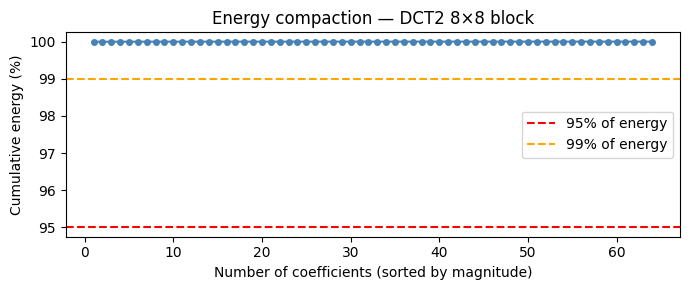

In [30]:
# --- Demo 1.1.v: DCT2 on an 8x8 block and a full frame ---
if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    frame0 = frames_y_car[0].astype(np.float64)

    # Individual 8x8 block
    sample_block = frame0[:8, :8]
    dct_block    = apply_dct(sample_block)
    rec_block    = apply_idct(dct_block)
    print(f"Original 8×8 block:\n{sample_block.astype(int)}")
    print(f"DCT2 coefficients (rounded):\n{np.round(dct_block, 1)}")
    print(f"Max. reconstruction error (IDCT): {np.max(np.abs(sample_block - rec_block)):.2e}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    im0 = axes[0].imshow(sample_block, cmap='gray')
    axes[0].set_title('Original block (8×8)'); plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(np.log1p(np.abs(dct_block)), cmap='hot')
    axes[1].set_title('DCT2 (log scale)'); plt.colorbar(im1, ax=axes[1])
    im2 = axes[2].imshow(rec_block, cmap='gray')
    axes[2].set_title('IDCT2 (reconstructed)'); plt.colorbar(im2, ax=axes[2])
    plt.suptitle('DCT2 on an 8×8 block')
    plt.tight_layout(); plt.show()

    # Full-frame DCT
    dct_full = apply_dct_to_frame(frame0)
    rec_full = apply_idct_to_frame(dct_full)
    err_full = np.max(np.abs(frame0 - rec_full))
    print(f"\nFull-frame DCT2 — max. reconstruction error: {err_full:.2e}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(frame0, cmap='gray');                          axes[0].set_title('Original frame')
    axes[1].imshow(np.log1p(np.abs(dct_full)), cmap='hot');       axes[1].set_title('DCT2 frame (log |coefs|)')
    axes[2].imshow(np.clip(rec_full,0,255), cmap='gray');         axes[2].set_title('Reconstructed frame (IDCT2)')
    for ax in axes: ax.axis('off')
    plt.suptitle('DCT2 applied to the full frame (8×8 blocks)')
    plt.tight_layout(); plt.show()

    # Energy compaction: % of energy in the first k coefficients (simplified zigzag order)
    coefs = np.abs(dct_block.flatten())
    coefs_sorted = np.sort(coefs)[::-1]
    total_energy = np.sum(coefs_sorted**2)
    cumulative   = np.cumsum(coefs_sorted**2) / total_energy * 100
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(range(1, 65), cumulative, 'o-', color='steelblue', markersize=4)
    ax.axhline(95, color='red', linestyle='--', label='95% of energy')
    ax.axhline(99, color='orange', linestyle='--', label='99% of energy')
    ax.set_xlabel('Number of coefficients (sorted by magnitude)')
    ax.set_ylabel('Cumulative energy (%)')
    ax.set_title('Energy compaction — DCT2 8×8 block')
    ax.legend(); plt.tight_layout(); plt.show()

else:
    print("[INFO] frames_y_car not available.")



---
## 1.1.vi — Matrix-Based Quantisation (I, P, B Modes)

The quantisation matrices and the functions `quantize` / `dequantize` follow the professor's **annex** (MPEG defaults).  
This version selects the appropriate matrix based on the coding mode (I vs P/B).


In [31]:
# =============================================================
# MPEG DEFAULT MATRICES — from the professor's annex (unchanged)
# Q_INTRA  : used in I mode (full pixel values)
# Q_INTER  : used in P and B modes (difference/residual values)
# =============================================================

Q_INTRA = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68, 109, 103,  77],
    [24, 35, 55, 64, 81, 104, 113,  92],
    [49, 64, 78, 87,103, 121, 120, 101],
    [72, 92, 95, 98,112, 100, 103,  99],
], dtype=np.float64)

# Inter matrix (MPEG-1 default inter quantization matrix)
Q_INTER = np.array([
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
    [16, 16, 16, 16, 16, 16, 16, 16],
], dtype=np.float64)


def quantize_block(block, mode='I', scale=1):
    """
    1.1.vi — Quantisation of an 8x8 block using an MPEG matrix.

    Parameters
    ----------
    block : 8x8 array of DCT coefficients
    mode  : 'I' uses Q_INTRA; 'P' or 'B' uses Q_INTER
    scale : quantiser scale factor

    Returns
    -------
    Int array of quantised coefficients (integer division).
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return np.floor(block / (Q * scale)).astype(int)


def dequantize_block(block, mode='I', scale=1):
    """
    2.1.i — Inverse quantisation (also used in Part 2).

    Parameters
    ----------
    block : 8x8 array of quantised coefficients
    mode  : 'I', 'P' or 'B'
    scale : same factor used during quantisation
    """
    Q = Q_INTRA if mode == 'I' else Q_INTER
    return (block * (Q * scale)).astype(np.float64)


def quantize_frame(dct_frame, mode='I', scale=1, block_size=8):
    """Apply quantize_block to all blocks of a DCT-transformed frame."""
    H, W = dct_frame.shape
    q_frame = np.zeros_like(dct_frame, dtype=int)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = dct_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                q_frame[i:i+block_size, j:j+block_size] = quantize_block(blk, mode, scale)
    return q_frame


def dequantize_frame(q_frame, mode='I', scale=1, block_size=8):
    """Apply dequantize_block to all blocks of a quantised frame."""
    H, W = q_frame.shape
    dq_frame = np.zeros_like(q_frame, dtype=np.float64)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            blk = q_frame[i:i+block_size, j:j+block_size]
            if blk.shape == (block_size, block_size):
                dq_frame[i:i+block_size, j:j+block_size] = dequantize_block(blk, mode, scale)
    return dq_frame

def psnr(original, compressed):
    mse_val = np.mean((original.astype(np.float64) - compressed.astype(np.float64)) ** 2)
    if mse_val == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse_val))

def compute_ssim(original, compressed):
    o = original.astype(np.uint8)
    c = np.clip(compressed, 0, 255).astype(np.uint8)
    return ssim(o, c, data_range=c.max() - c.min())


print("Functions 1.1.vi (quantisation) defined successfully.")


Functions 1.1.vi (quantisation) defined successfully.


---
### Demo 1.1.vi — Quantisation Matrices Visualisation and Scale Factor Effect



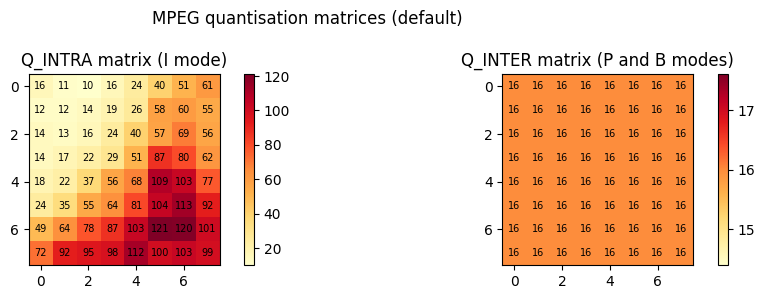

  QS= 1 | PSNR=15.49 dB | non-zero coefs: 53.4%
  QS= 2 | PSNR=11.33 dB | non-zero coefs: 52.2%
  QS= 4 | PSNR=8.54 dB | non-zero coefs: 51.4%
  QS= 8 | PSNR=7.06 dB | non-zero coefs: 50.9%


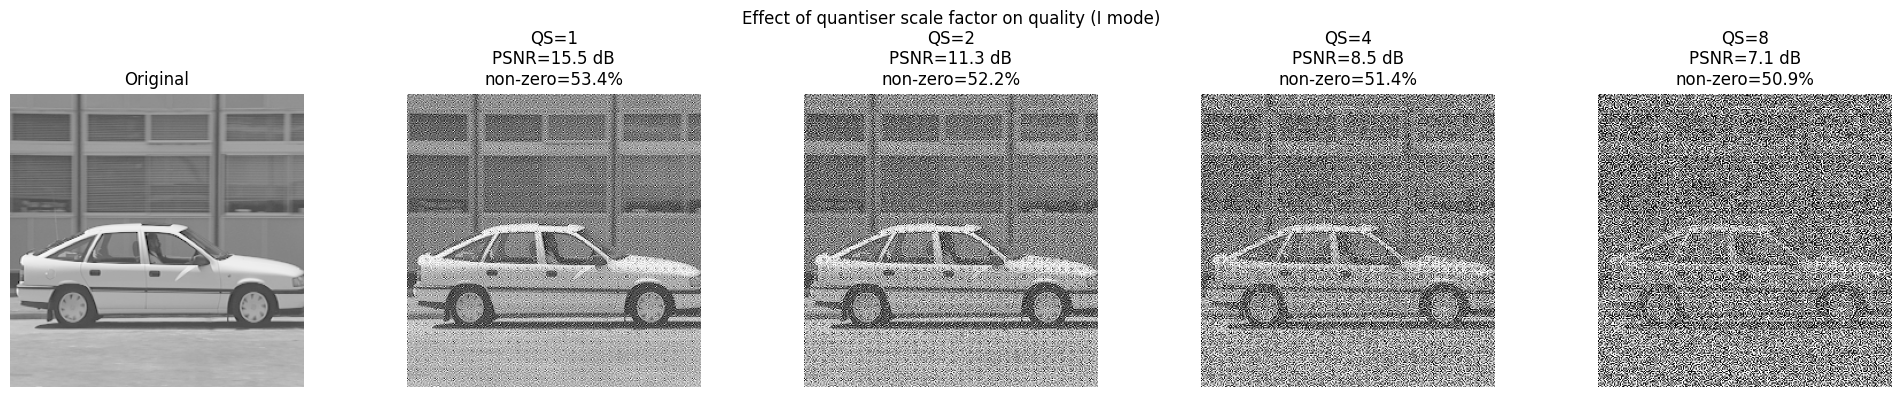

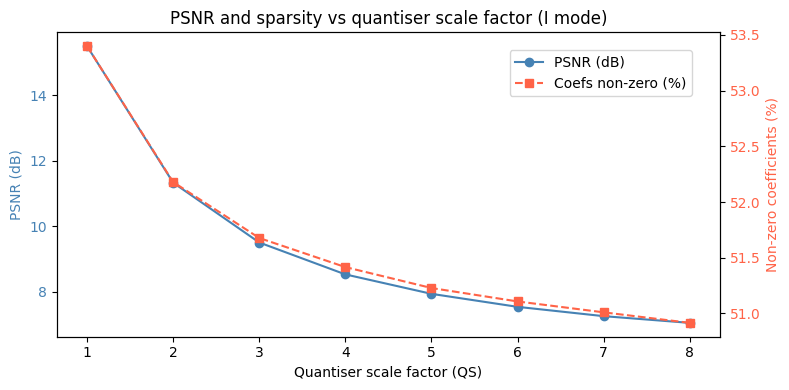

In [32]:
# --- Demo 1.1.vi: effect of quantisation ---
if 'frames_y_car' in dir() and len(frames_y_car) > 0:
    frame0 = frames_y_car[0].astype(np.float64)
    dct_f  = apply_dct_to_frame(frame0)

    # Visualisation of Q_INTRA and Q_INTER matrices
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    im0 = axes[0].imshow(Q_INTRA, cmap='YlOrRd')
    axes[0].set_title('Q_INTRA matrix (I mode)')
    plt.colorbar(im0, ax=axes[0])
    for i in range(8):
        for j in range(8):
            axes[0].text(j, i, int(Q_INTRA[i,j]), ha='center', va='center', fontsize=7)
    im1 = axes[1].imshow(Q_INTER, cmap='YlOrRd')
    axes[1].set_title('Q_INTER matrix (P and B modes)')
    plt.colorbar(im1, ax=axes[1])
    for i in range(8):
        for j in range(8):
            axes[1].text(j, i, int(Q_INTER[i,j]), ha='center', va='center', fontsize=7)
    plt.suptitle('MPEG quantisation matrices (default)')
    plt.tight_layout(); plt.show()

    # Effect of quant_scale on reconstruction — I mode
    scales  = [1, 2, 4, 8]
    fig, axes = plt.subplots(1, len(scales)+1, figsize=(4*(len(scales)+1), 4))
    axes[0].imshow(frame0, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
    for ax, qs in zip(axes[1:], scales):
        q  = quantize_frame(dct_f, mode='I', scale=qs)
        dq = dequantize_frame(q, mode='I', scale=qs)
        rc = np.clip(apply_idct_to_frame(dq), 0, 255)
        psnr_val = psnr(frame0, rc)
        nz_ratio = np.sum(q != 0) / q.size * 100
        ax.imshow(rc, cmap='gray')
        ax.set_title(f'QS={qs}\nPSNR={psnr_val:.1f} dB\nnon-zero={nz_ratio:.1f}%')
        ax.axis('off')
        print(f"  QS={qs:2d} | PSNR={psnr_val:.2f} dB | non-zero coefs: {nz_ratio:.1f}%")
    plt.suptitle('Effect of quantiser scale factor on quality (I mode)')
    plt.tight_layout(); plt.show()

    # PSNR vs quant_scale (line plot)
    qs_range   = list(range(1, 9))
    psnr_vals  = []
    nz_vals    = []
    for qs in qs_range:
        q  = quantize_frame(dct_f, mode='I', scale=qs)
        dq = dequantize_frame(q, mode='I', scale=qs)
        rc = np.clip(apply_idct_to_frame(dq), 0, 255)
        psnr_vals.append(psnr(frame0, rc))
        nz_vals.append(np.sum(q != 0) / q.size * 100)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    color1 = 'steelblue'
    ax1.plot(qs_range, psnr_vals, 'o-', color=color1, label='PSNR (dB)')
    ax1.set_xlabel('Quantiser scale factor (QS)')
    ax1.set_ylabel('PSNR (dB)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax2 = ax1.twinx()
    ax2.plot(qs_range, nz_vals, 's--', color='tomato', label='Coefs non-zero (%)')
    ax2.set_ylabel('Non-zero coefficients (%)', color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')
    ax1.set_title('PSNR and sparsity vs quantiser scale factor (I mode)')
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout(); plt.show()
else:
    print("[INFO] frames_y_car not available.")



---
## 1.2 — Main Encoder Script (GOP + Storage + Bit Analysis)


In [33]:
def generate_gop_sequence(n_frames, N, M):
    """
    Generate the frame type sequence ('I', 'P', 'B') for a GOP.

    Parameters
    ----------
    n_frames : total number of frames
    N        : GOP length (e.g. 12 → I + 11 P/B)
    M        : distance between P anchor frames (e.g. M=3 → IBBP BBPBBP ...)
               M=1 → P-frames only (IPPP...)

    Returns
    -------
    List of strings: ['I','B','B','P','B','B','P', ...]
    """
    seq = []
    for idx in range(n_frames):
        pos_in_gop = idx % N
        if pos_in_gop == 0:
            seq.append('I')
        elif pos_in_gop % M == 0:
            seq.append('P')
        else:
            seq.append('B')
    return seq


# Quick test
for (N, M) in [(12, 3), (9, 1), (6, 2)]:
    seq = generate_gop_sequence(12, N=N, M=M)
    print(f"N={N}, M={M}: {seq}")


N=12, M=3: ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B']
N=9, M=1: ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P', 'P']
N=6, M=2: ['I', 'B', 'P', 'B', 'P', 'B', 'I', 'B', 'P', 'B', 'P', 'B']


In [34]:
def count_bits(q_frame, mv_list=None):
    """
    Estimated bits needed to store:
    - quantised DCT coefficients (non-zero × bits per symbol)
    - motion vectors

    This is a simplified estimate; no real entropy coding is applied.
    """
    # Bits for coefficients: uses ceil(log2(|val|+1)) per non-zero coefficient
    nonzero = q_frame[q_frame != 0]
    if len(nonzero) == 0:
        coeff_bits = 0
    else:
        coeff_bits = int(np.sum(np.ceil(np.log2(np.abs(nonzero) + 1)) + 1))  # +1 for sign bit

    # Bits for MVs: 8 bits per component × 2 components
    mv_bits = 0
    if mv_list:
        mv_bits = len(mv_list) * 2 * 8

    return coeff_bits + mv_bits


print("Bit counting utility defined.")


Bit counting utility defined.


In [35]:
# =============================================================
# 1.2 — MAIN ENCODER
# =============================================================

def encode_sequence(frames_y, gop_N=12, gop_M=3,
                    block_size=16, search_range=8,
                    quant_scale=1, output_dir='compressed'):
    """
    1.2 — Encodes a Y-channel frame sequence according to a GOP structure.

    Parameters
    ----------
    frames_y     : list of frames (np.ndarray 2D, uint8)
    gop_N        : GOP length
    gop_M        : distance between P-frames (M=1 → P only)
    block_size   : macroblock size (16 or 8)
    search_range : ME search window
    quant_scale  : quantiser scale factor
    output_dir   : folder to save the compressed files

    Returns
    -------
    compressed_data : list of dicts with per-frame data
    total_bits      : total estimated bits
    """
    os.makedirs(output_dir, exist_ok=True)

    n_frames   = len(frames_y)
    gop_seq    = generate_gop_sequence(n_frames, gop_N, gop_M)
    compressed = []
    total_bits = 0

    # Buffer of decoded frames (needed for prediction)
    decoded_buffer = [None] * n_frames

    print(f"\n{'='*60}")
    print(f"ENCODER | GOP N={gop_N} M={gop_M} | MB={block_size}×{block_size} "
          f"| SR={search_range} | QS={quant_scale}")
    print(f"GOP sequence ({n_frames} frames): {gop_seq[:min(20, n_frames)]}...")
    print(f"{'='*60}")

    for idx, frame in enumerate(frames_y):
        ftype = gop_seq[idx]

        # ---- I-frame -----------------------------------------------
        if ftype == 'I':
            dct_f   = apply_dct_to_frame(frame.astype(np.float64))
            q_f     = quantize_frame(dct_f, mode='I', scale=quant_scale)
            bits    = count_bits(q_f, mv_list=None)
            record  = {'frame_idx': idx, 'type': 'I',
                       'q_frame': q_f, 'mv_list': [],
                       'block_size': block_size, 'scale': quant_scale}
            # Local reconstruction (for use as future reference)
            dq_f    = dequantize_frame(q_f, mode='I', scale=quant_scale)
            rec     = np.clip(apply_idct_to_frame(dq_f), 0, 255).astype(np.uint8)
            decoded_buffer[idx] = rec

        # ---- P-frame -----------------------------------------------
        elif ftype == 'P':
            # Find the previous decoded I/P frame
            ref_idx = idx - 1
            while ref_idx >= 0 and gop_seq[ref_idx] == 'B':
                ref_idx -= 1
            ref = decoded_buffer[ref_idx] if ref_idx >= 0 else frames_y[0]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref], mode='P',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='P', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'P',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'ref_idx': ref_idx,
                      'block_size': block_size, 'scale': quant_scale}
            # Local reconstruction
            dq_r   = dequantize_frame(q_r, mode='P', scale=quant_scale)
            res_rec = apply_idct_to_frame(dq_r)
            # Reconstruct frame by adding residual to prediction
            rec_frame = np.zeros_like(frame, dtype=np.float64)
            mb = block_size
            H, W = frame.shape
            for mv in mv_list:
                ri, ci, dx, dy, _ = mv[:5]
                i, j = ri * mb, ci * mb
                pred_i = min(i + dx, H - mb); pred_j = min(j + dy, W - mb)
                pred_i = max(pred_i, 0);      pred_j = max(pred_j, 0)
                rec_frame[i:i+mb, j:j+mb] = (
                    ref[pred_i:pred_i+mb, pred_j:pred_j+mb].astype(np.float64)
                    + res_rec[i:i+mb, j:j+mb]
                )
            decoded_buffer[idx] = np.clip(rec_frame, 0, 255).astype(np.uint8)

        # ---- B-frame -----------------------------------------------
        else:  # 'B'
            # Forward ref: previous I/P frame
            fwd_idx = idx - 1
            while fwd_idx >= 0 and gop_seq[fwd_idx] == 'B':
                fwd_idx -= 1
            # Backward ref: next I/P frame
            bwd_idx = idx + 1
            while bwd_idx < n_frames and gop_seq[bwd_idx] == 'B':
                bwd_idx += 1
            bwd_idx = min(bwd_idx, n_frames - 1)

            ref_fwd = decoded_buffer[fwd_idx] if (fwd_idx >= 0 and decoded_buffer[fwd_idx] is not None) else frames_y[0]
            # Backward not yet decoded → use original frame as proxy
            ref_bwd = frames_y[bwd_idx]

            mv_list, residual = compute_motion_and_residual(
                frame, [ref_fwd, ref_bwd], mode='B',
                search_range=search_range, block_size=block_size
            )
            dct_r  = apply_dct_to_frame(residual.astype(np.float64))
            q_r    = quantize_frame(dct_r, mode='B', scale=quant_scale)
            bits   = count_bits(q_r, mv_list)
            record = {'frame_idx': idx, 'type': 'B',
                      'q_frame': q_r, 'mv_list': mv_list,
                      'fwd_idx': fwd_idx, 'bwd_idx': bwd_idx,
                      'block_size': block_size, 'scale': quant_scale}
            decoded_buffer[idx] = frame.copy()  # B-frames are not used as reference

        total_bits += bits
        compressed.append(record)
        print(f"  Frame {idx:3d} [{ftype}] | estimated bits: {bits:8,d}")

    # Save to disk (.npz format — compressed NumPy arrays)
    out_path = os.path.join(output_dir,
        f"compressed_N{gop_N}_M{gop_M}_MB{block_size}_QS{quant_scale}.npz")

    # Serialise all data as numpy arrays
    q_frames    = np.array([r['q_frame']   for r in compressed], dtype=object)
    frame_types = np.array([r['type']       for r in compressed])
    frame_idxs  = np.array([r['frame_idx'] for r in compressed], dtype=np.int32)
    scales      = np.array([r['scale']      for r in compressed], dtype=np.float32)
    blk_sizes   = np.array([r['block_size'] for r in compressed], dtype=np.int32)
    ref_idxs    = np.array([r.get('ref_idx', r.get('fwd_idx', -1)) for r in compressed], dtype=np.int32)
    bwd_idxs    = np.array([r.get('bwd_idx', -1) for r in compressed], dtype=np.int32)
    mv_array    = np.empty(len(compressed), dtype=object)
    for k, r in enumerate(compressed):
        mv_array[k] = r['mv_list']

    np.savez_compressed(
        out_path,
        q_frames            = q_frames,
        frame_types         = frame_types,
        frame_idxs          = frame_idxs,
        scales              = scales,
        blk_sizes           = blk_sizes,
        ref_idxs            = ref_idxs,
        bwd_idxs            = bwd_idxs,
        mv_array            = mv_array,
        gop_seq             = np.array(gop_seq),
        params_N            = np.int32(gop_N),
        params_M            = np.int32(gop_M),
        params_block_size   = np.int32(block_size),
        params_search_range = np.int32(search_range),
        params_quant_scale  = np.float32(quant_scale),
    )

    print(f"\n  Total estimated bits: {total_bits:,}")
    print(f"  File saved: {out_path}")
    return compressed, total_bits


print("Encoder (1.2) defined successfully.")


Encoder (1.2) defined successfully.


---
## 1.2 — Running the Experiments

Tests different GOP configurations, MB sizes and quantiser scale factors, comparing the total number of bits.


In [36]:
# =============================================================
# EXPERIMENTS — 'car' sequence (BMP)
# =============================================================

CAR_FOLDER = 'video sequences/sequence of still images - car'

if os.path.isdir(CAR_FOLDER):
    frames_y, _ = load_image_sequence(CAR_FOLDER, extension='.bmp', color_space='YCrCb')

    # Configurations to test
    experiments = [
        # (GOP_N, GOP_M, MB_size, quant_scale, label)
        (9,  1, 16, 1,   'IPPP  MB16 QS1'),
        (9,  3, 16, 1,   'IBBP  MB16 QS1'),
        (9,  3, 8,  1,   'IBBP  MB8  QS1'),
        (9,  3, 16, 2,   'IBBP  MB16 QS2'),
        (12, 3, 16, 1,   'IBBP  MB16 QS1 N12'),
    ]

    results         = []
    results_per_frame = []

    for (N, M, mb, qs, label) in experiments:
        print(f"\n>>> Experiment: {label}")
        compressed_data, bits = encode_sequence(
            frames_y,
            gop_N=N, gop_M=M,
            block_size=mb,
            search_range=8,
            quant_scale=qs,
            output_dir='compressed'
        )
        results.append({'label': label, 'bits': bits, 'N': N, 'M': M, 'mb': mb, 'qs': qs})
        results_per_frame.append({'label': label, 'data': compressed_data})

    print("\n" + "="*60)
    print("EXPERIMENT SUMMARY")
    print("="*60)
    for r in results:
        print(f"  {r['label']:<25} | Total bits: {r['bits']:>12,}")
else:
    print(f"[INFO] Folder '{CAR_FOLDER}' not found. Adjust the path.")



[load_image_sequence] Loaded 11 frames from 'video sequences/sequence of still images - car'
  Colour space: YCrCb | Resolution: (256, 256)

>>> Experiment: IPPP  MB16 QS1

ENCODER | GOP N=9 M=1 | MB=16×16 | SR=8 | QS=1
GOP sequence (11 frames): ['I', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'P', 'I', 'P']...
  Frame   0 [I] | estimated bits:   81,185
  Frame   1 [P] | estimated bits:  162,055
  Frame   2 [P] | estimated bits:   73,667
  Frame   3 [P] | estimated bits:   88,405
  Frame   4 [P] | estimated bits:   67,913
  Frame   5 [P] | estimated bits:   73,456
  Frame   6 [P] | estimated bits:   74,426
  Frame   7 [P] | estimated bits:   75,936
  Frame   8 [P] | estimated bits:   76,061
  Frame   9 [I] | estimated bits:   81,942
  Frame  10 [P] | estimated bits:  156,013

  Total estimated bits: 1,011,059
  File saved: compressed/compressed_N9_M1_MB16_QS1.npz

>>> Experiment: IBBP  MB16 QS1

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
GOP sequence (11 frames): ['I', 'B', 'B', 'P', 'B', 

/tmp/ipykernel_955/3851824590.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right')


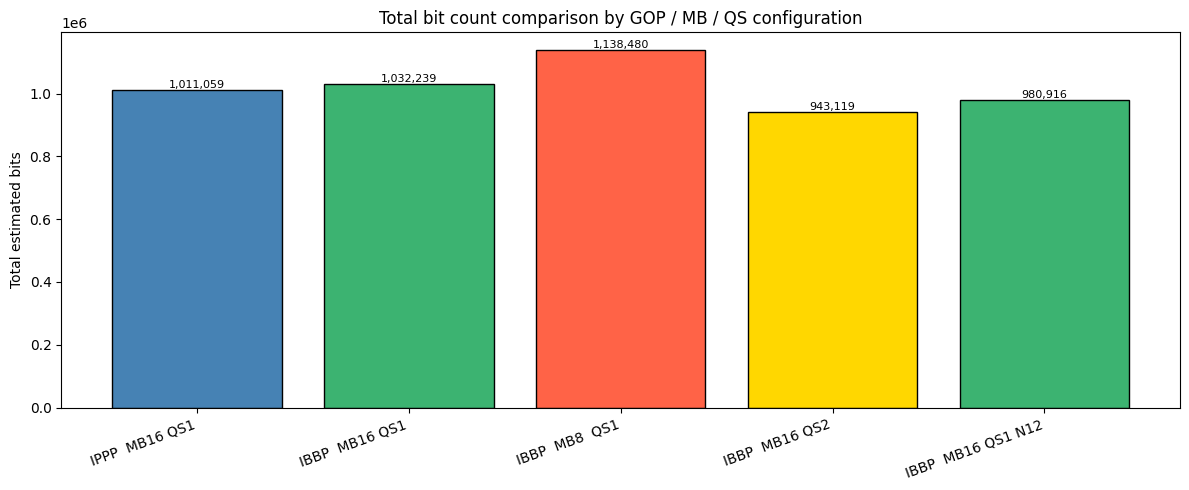

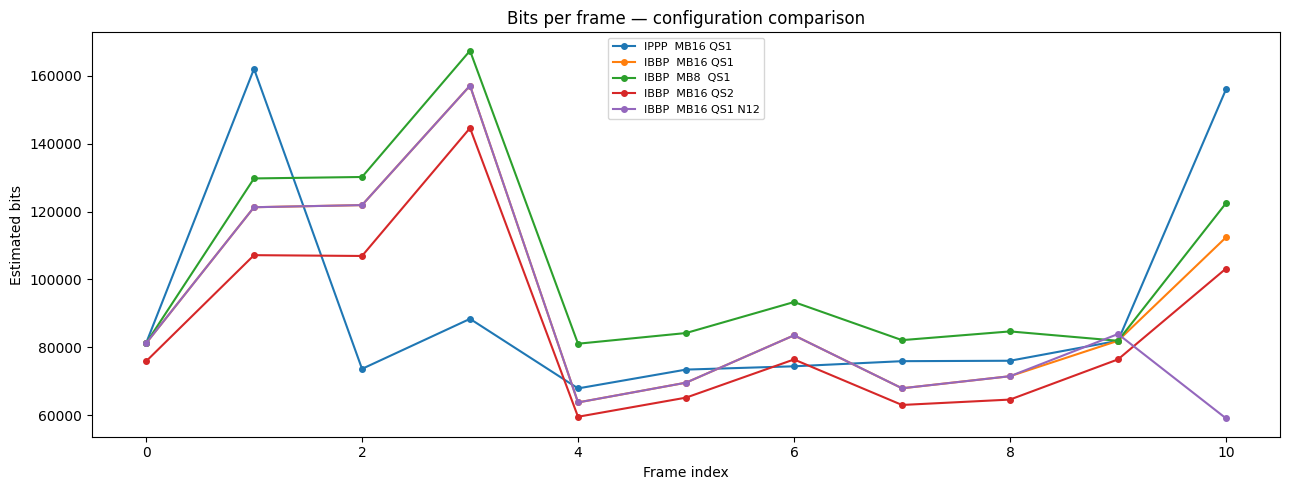


Configuration             |    Total bits |  Bits/frame |   GOP |   MB |   QS
------------------------------------------------------------------------
  IPPP  MB16 QS1          |     1,011,059 |    91,914.5 | N= 9 M=1 | 16px |    1
  IBBP  MB16 QS1          |     1,032,239 |    93,839.9 | N= 9 M=3 | 16px |    1
  IBBP  MB8  QS1          |     1,138,480 |   103,498.2 | N= 9 M=3 |  8px |    1
  IBBP  MB16 QS2          |       943,119 |    85,738.1 | N= 9 M=3 | 16px |    2
  IBBP  MB16 QS1 N12      |       980,916 |    89,174.2 | N=12 M=3 | 16px |    1


In [37]:
# --- Experiment analysis charts ---
if 'results' in dir() and results:

    # 1. Bar chart — total bits per configuration
    labels = [r['label'] for r in results]
    bits   = [r['bits']  for r in results]
    colors = ['steelblue' if r['M'] == 1 else
              ('tomato' if r['mb'] == 8 else
               ('gold' if r['qs'] > 1 else 'mediumseagreen'))
              for r in results]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels, bits, color=colors, edgecolor='black')
    ax.set_ylabel('Total estimated bits')
    ax.set_title('Total bit count comparison by GOP / MB / QS configuration')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    for bar, b in zip(bars, bits):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{b:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

    # 2. Bits per frame — for each experiment
    if 'results_per_frame' in dir():
        fig, ax = plt.subplots(figsize=(13, 5))
        type_colors = {'I': 'red', 'P': 'blue', 'B': 'green'}
        for exp in results_per_frame:
            frame_bits = [count_bits(r['q_frame'], r['mv_list']) for r in exp['data']]
            ax.plot(frame_bits, label=exp['label'], marker='o', markersize=4)
        ax.set_xlabel('Frame index')
        ax.set_ylabel('Estimated bits')
        ax.set_title('Bits per frame — configuration comparison')
        ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()

    # 3. Summary table
    print(f"\n{'Configuration':<25} | {'Total bits':>13} | {'Bits/frame':>11} | {'GOP':>5} | {'MB':>4} | {'QS':>4}")
    print("-" * 72)
    for r in results:
        n_frames = len(frames_y) if 'frames_y' in dir() else 1
        bpf = r['bits'] / n_frames
        print(f"  {r['label']:<23} | {r['bits']:>13,} | {bpf:>11,.1f} | N={r['N']:2d} M={r['M']} | {r['mb']:>2d}px | {r['qs']:>4}")



In [38]:
# =============================================================
# EXPERIMENT — MP4 Video (input.mp4)
# Uses the crop_frames_to_multiples_of_8 function from the professor
# =============================================================

VIDEO_PATH = 'video sequences/input.mp4'

if os.path.isfile(VIDEO_PATH):
    print("Extracting video frames (this may take a while)...")
    frames_video = crop_frames_to_multiples_of_8(VIDEO_PATH)
    # Limit to 30 frames for a quick demo
    frames_demo = frames_video[:30]
    print(f"Using {len(frames_demo)} frames for the experiment.")

    _, bits_video = encode_sequence(
        frames_demo,
        gop_N=9, gop_M=3,
        block_size=16, search_range=8,
        quant_scale=1,
        output_dir='compressed'
    )
    print(f"\nVideo input.mp4 (30 frames) | Estimated bits: {bits_video:,}")
else:
    print(f"[INFO] Video '{VIDEO_PATH}' not found.")


Extracting video frames (this may take a while)...
Using 30 frames for the experiment.

ENCODER | GOP N=9 M=3 | MB=16×16 | SR=8 | QS=1
GOP sequence (30 frames): ['I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B', 'B', 'P', 'B', 'B', 'P', 'B', 'B', 'I', 'B']...
  Frame   0 [I] | estimated bits:  350,089
  Frame   1 [B] | estimated bits:  478,500
  Frame   2 [B] | estimated bits:  481,863
  Frame   3 [P] | estimated bits:  659,340
  Frame   4 [B] | estimated bits:  215,307
  Frame   5 [B] | estimated bits:  209,982
  Frame   6 [P] | estimated bits:  254,958
  Frame   7 [B] | estimated bits:  214,201
  Frame   8 [B] | estimated bits:  210,088
  Frame   9 [I] | estimated bits:  362,888
  Frame  10 [B] | estimated bits:  504,420
  Frame  11 [B] | estimated bits:  505,544
  Frame  12 [P] | estimated bits:  697,324
  Frame  13 [B] | estimated bits:  221,849
  Frame  14 [B] | estimated bits:  225,444
  Frame  15 [P] | estimated bits:  254,411
  Frame  16 [B] | estimated bits:  221,384
  Fr

---
## Conclusion

The compressed files (quantised DCT data + motion vectors) are saved in the `compressed/` folder in `.npz` format (NumPy compressed arrays), one per tested configuration.

Each `.npz` file contains the following named arrays:

| Array | Contents |
|---|---|
| `q_frames` | Quantised DCT coefficients for each frame |
| `frame_types` | Type of each frame (`'I'`, `'P'`, `'B'`) |
| `mv_array` | Motion vectors per frame (list of tuples) |
| `gop_seq` | Full GOP sequence |
| `ref_idxs` / `bwd_idxs` | Forward/backward reference frame indices |
| `params_*` | Encoding parameters (N, M, block_size, QS, SR) |

These files will be read in **Part 2** (decoder + PSNR/SSIM quality evaluation).



In [39]:
# List the generated .npz files and display their contents
if os.path.isdir('compressed'):
    files = sorted([f for f in os.listdir('compressed') if f.endswith('.npz')])
    print(f".npz files in 'compressed/' ({len(files)} total):\n")
    print(f"{'File':<55} {'Size':>10}  {'Frames':>7}  {'Stored arrays'}") 
    print("-" * 100)
    for fname in files:
        fpath    = os.path.join('compressed', fname)
        size_kb  = os.path.getsize(fpath) / 1024
        data     = np.load(fpath, allow_pickle=True)
        n_frames = len(data['frame_types'])
        keys     = ', '.join(data.files)
        print(f"  {fname:<53} {size_kb:>9.1f} KB  {n_frames:>7}  {keys}")
        # Frame type distribution
        ftypes = data['frame_types']
        counts = {t: int(np.sum(ftypes == t)) for t in ['I','P','B']}
        print(f"    └─ Types: I={counts['I']}  P={counts['P']}  B={counts['B']}  "
              f"| QS={data['params_quant_scale']:.0f}  MB={data['params_block_size']}  "
              f"N={data['params_N']}  M={data['params_M']}")
else:
    print("Folder 'compressed/' does not exist yet. Run the experiments above.")



.npz files in 'compressed/' (5 total):

File                                                          Size   Frames  Stored arrays
----------------------------------------------------------------------------------------------------
  compressed_N12_M3_MB16_QS1.npz                            301.6 KB       11  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_array, gop_seq, params_N, params_M, params_block_size, params_search_range, params_quant_scale
    └─ Types: I=1  P=3  B=7  | QS=1  MB=16  N=12  M=3
  compressed_N9_M1_MB16_QS1.npz                             317.4 KB       11  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_array, gop_seq, params_N, params_M, params_block_size, params_search_range, params_quant_scale
    └─ Types: I=2  P=9  B=0  | QS=1  MB=16  N=9  M=1
  compressed_N9_M3_MB16_QS1.npz                            3294.7 KB       30  q_frames, frame_types, frame_idxs, scales, blk_sizes, ref_idxs, bwd_idxs, mv_arr